# Data Collection
## Clean Finance Data

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
import statsmodels.api as sm

# Display and plotting options
pd.options.display.float_format = "{:.4f}".format
plt.rcParams["figure.figsize"] = (10, 4)

DATA_DIR = "./data/"
OUTPUT_DIR = "./data/"

RAW_FINANCIAL_FILE = DATA_DIR + "market_data.json"
FINANCIAL_PANEL_FILE = OUTPUT_DIR + "financial_returns_and_controls.parquet"
FINANCIAL_PANEL_CSV = OUTPUT_DIR + "financial_returns_and_controls.csv"

# Analysis window
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"


## 1. Load Raw Data

In [ ]:
try:
    df_raw = pd.read_json(RAW_FINANCIAL_FILE)
except ValueError:
    df_raw = pd.read_csv(RAW_FINANCIAL_FILE)

# Basic cleaning: parse dates and sort
if "Date_" in df_raw.columns:
    df_raw["Date_"] = pd.to_datetime(df_raw["Date_"])
    df_raw = df_raw.sort_values("Date_").set_index("Date_")
else:
    # Adjust here if your date column has a different name
    raise KeyError("Expected a 'Date_' column. Please adjust the code to your date column name.")

print(df_raw.head())
print(df_raw.info())

## 2. Rename columns

In [ ]:
# Inspect available columns
df_raw.columns

In [ ]:
# Define a renaming map
rename_map = {
    "Close_BTC-USD": "close_btc",
    "Open_BTC-USD": "open_btc",
    "High_BTC-USD": "high_btc",
    "Low_BTC-USD": "low_btc",
    "Volume_BTC-USD": "vol_btc",

    "Close_GC=F": "close_gold",
    "Open_GC=F": "open_gold",
    "High_GC=F": "high_gold",
    "Low_GC=F": "low_gold",
    "Volume_GC=F": "vol_gold",

    "Close_CL=F": "close_oil",
    "Open_CL=F": "open_oil",
    "High_CL=F": "high_oil",
    "Low_CL=F": "low_oil",
    "Volume_CL=F": "vol_oil",

    "Close_^GSPC": "close_spx",
    "Open_^GSPC": "open_spx",
    "High_^GSPC": "high_spx",
    "Low_^GSPC": "low_spx",
    "Volume_^GSPC": "vol_spx",

    "Close_CNY=X": "close_usdcny",
    "Open_CNY=X": "open_usdcny",
    "High_CNY=X": "high_usdcny",
    "Low_CNY=X": "low_usdcny",
    "Volume_CNY=X": "vol_usdcny",

    "Close_EUR=X": "close_eurusd",
    "Open_EUR=X": "open_eurusd",
    "High_EUR=X": "high_eurusd",
    "Low_EUR=X": "low_eurusd",
    "Volume_EUR=X": "vol_eurusd",

    "Close_^TNX": "close_ust10y",
    "Open_^TNX": "open_ust10y",
    "High_^TNX": "high_ust10y",
    "Low_^TNX": "low_ust10y",
    "Volume_^TNX": "vol_ust10y",
}

df = df_raw.rename(columns=rename_map)

print("After renaming:")
print(df.head())

## 3. Align frequencies and handle non-trading days

We keep the native trading-day calendar (no synthetic weekend/holiday rows). Prices are forward-filled within existing rows only, and a flag marks rows that needed filling.

In [ ]:
# Create a continuous business-day index over the sample
full_index = pd.date_range(df.index.min(), df.index.max(), freq="B")
df = df.reindex(full_index)

# Identify price and volume columns
price_cols = [c for c in df.columns if c.startswith(("close_", "open_", "high_", "low_"))]
volume_cols = [c for c in df.columns if c.startswith("vol_")]

# Track rows where prices were missing prior to forward-fill
missing_price_rows = df[price_cols].isna().any(axis=1)

# Forward-fill prices, leave volumes as-is
df[price_cols] = df[price_cols].ffill()

# Flag rows that relied on forward-filled prices
df["ffill_flag"] = missing_price_rows

print(df.head())

            close_btc  close_oil  close_usdcny  close_eurusd  close_gold  \
2024-11-18        NaN        NaN           NaN           NaN         NaN   
2024-11-19 92343.7891    69.3900        7.2354        0.9438   2627.1001   
2024-11-20 94339.4922    68.8700        7.2381        0.9427   2648.2000   
2024-11-21 98504.7266    70.1000        7.2440        0.9482   2672.1001   
2024-11-22 98997.6641    71.2400        7.2337        0.9552   2709.8999   

            close_spx  close_ust10y   high_btc  high_oil  high_usdcny  ...  \
2024-11-18        NaN        4.4140        NaN       NaN          NaN  ...   
2024-11-19  5916.9800        4.3790 94002.8672   69.6900       7.2428  ...   
2024-11-20  5917.1099        4.4060 94902.0234   70.1500       7.2461  ...   
2024-11-21  5948.7100        4.4320 99014.2188   70.3800       7.2459  ...   
2024-11-22  5969.3398        4.4100 99655.5000   71.5100       7.2487  ...   

            open_spx  open_ust10y           vol_btc     vol_oil  vol_usdcn


## 4. Construct returns and control variables

We compute:

- **Log returns** for Bitcoin, Gold, S&P 500.
- **Log differences** for FX and oil.
- **First difference** for the 10-year yield.


In [ ]:
def log_return(series):
    return np.log(series).diff()

returns = pd.DataFrame(index=df.index)

# Asset returns
returns["r_btc"] = log_return(df["close_btc"])
returns["r_gold"] = log_return(df["close_gold"])
returns["r_spx"] = log_return(df["close_spx"])

# Control variables
returns["dln_eurusd"] = log_return(df["close_eurusd"])   # USD/EUR
returns["dln_usdcny"] = log_return(df["close_usdcny"])   # USD/CNY
returns["dln_oil"] = log_return(df["close_oil"])
returns["dy10"] = df["close_ust10y"].diff()

# Drop initial NaNs from differencing
returns = returns.dropna()

# Restrict to analysis window
returns = returns.loc[START_DATE:END_DATE]

returns.head()

,r_btc,r_gold,r_spx,dln_eurusd,dln_usdcny,dln_oil,dy10
2025-01-01,0.0105,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2025-01-02,0.0258,0.0112,-0.0022,0.0052,0.0000,0.0195,0.0020
2025-01-03,0.0125,-0.0052,0.0125,0.0081,0.0001,0.0113,0.0210
2025-01-06,0.0397,-0.0025,0.0055,-0.0036,0.0029,-0.0054,0.0220
2025-01-07,-0.0518,0.0069,-0.0112,-0.0078,0.0004,0.0093,0.0650



## 5. Exploratory data analysis

Time-series plots, summary statistics, and correlations.


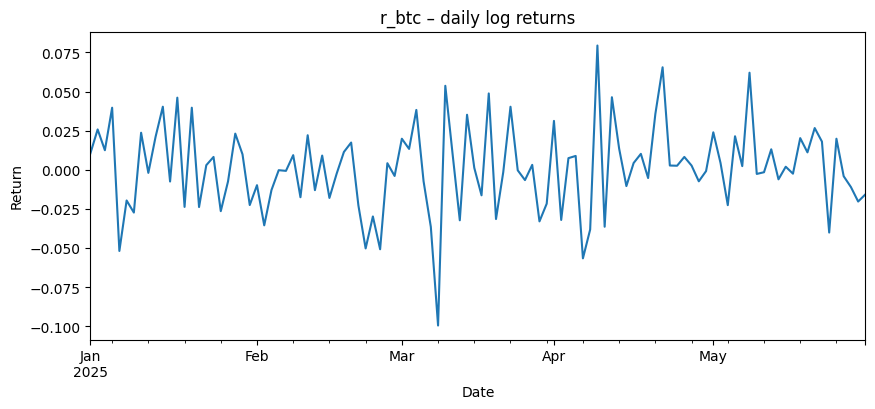

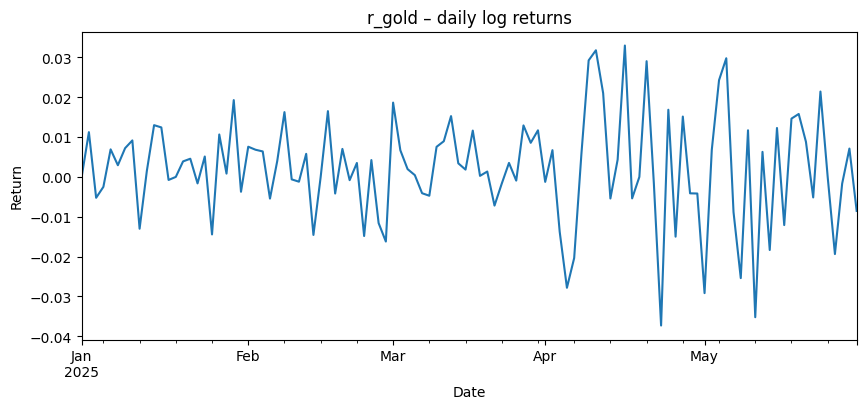

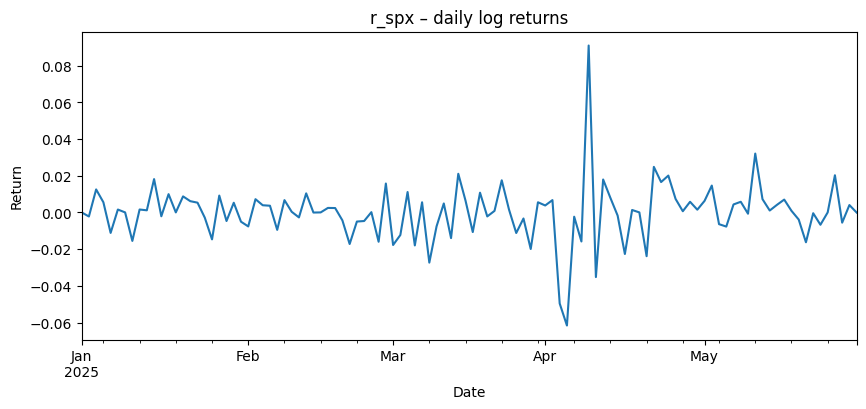

In [ ]:
# Plot returns
for col in ["r_btc", "r_gold", "r_spx"]:
    ax = returns[col].plot(title=f"{col} – daily log returns")
    ax.set_xlabel("Date")
    ax.set_ylabel("Return")
    plt.show()

In [ ]:
# Summary statistics
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
r_btc,108.0000,0.0010,0.0280,-0.0994,-0.0166,0.0016,0.0176,0.0794
r_gold,108.0000,0.0021,0.0133,-0.0373,-0.0042,0.0024,0.0090,0.0330
r_spx,108.0000,0.0000,0.0161,-0.0616,-0.0052,0.0007,0.0063,0.0909
dln_eurusd,108.0000,-0.0008,0.0062,-0.0275,-0.0042,0.0003,0.0026,0.0145
dln_usdcny,108.0000,-0.0001,0.0026,-0.0113,-0.0003,0.0000,0.0007,0.0123
dln_oil,108.0000,-0.0015,0.0200,-0.0770,-0.0153,0.0000,0.0096,0.0454
dy10,108.0000,-0.0015,0.0600,-0.1410,-0.0430,0.0000,0.0340,0.1700


In [ ]:
# Correlation matrix
corr = returns[["r_btc", "r_gold", "r_spx"]].corr()
corr

,r_btc,r_gold,r_spx
r_btc,1.0000,0.0504,0.3796
r_gold,0.0504,1.0000,-0.0177
r_spx,0.3796,-0.0177,1.0000



## 6. Stationarity checks (ADF tests)


In [ ]:
def adf_test(series, name=""):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF Test for {name}")
    print(f"  Test statistic: {result[0]:.4f}")
    print(f"  p-value:        {result[1]:.4f}")
    print("  Critical values:")
    for k, v in result[4].items():
        print(f"    {k}: {v:.4f}")
    print("-" * 40)

for col in returns.columns:
    adf_test(returns[col], name=col)

ADF Test for r_btc
  Test statistic: -11.3955
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for r_gold
  Test statistic: -10.2024
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for r_spx
  Test statistic: -11.3953
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for dln_eurusd
  Test statistic: -10.1000
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for dln_usdcny
  Test statistic: -10.4155
  p-value:        0.0000
  Critical values:
    1%: -3.4930
    5%: -2.8890
    10%: -2.5814
----------------------------------------
ADF Test for dln_oil
  Test statistic: -5.0250
  p-value:        0.0000
  Critical values

## 7. Export dataset
We export a panel containing the returns and control variables for reuse in the emotion/EPI notebook.

In [ ]:
panel = returns.copy()

# Optionally include event dummies or other flags
# panel = returns_events

panel.to_parquet(FINANCIAL_PANEL_FILE)
panel.to_csv(FINANCIAL_PANEL_CSV)

print("Saved financial panel to:")
print("  ", FINANCIAL_PANEL_FILE)
print("  ", FINANCIAL_PANEL_CSV)

Saved financial panel to:
   ./data/financial_returns_and_controls.parquet
   ./data/financial_returns_and_controls.csv
